In [1]:
from src.adasecant import Adasecant
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor


# Pierwszy test czy działa

In [2]:
# 1. Konfiguracja urządzenia
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Używam urządzenia: {device}")

# 2. Pobieranie danych
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

# 3. Tworzenie DataLoaderów
batch_size = 64
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

# 4. Definicja modelu
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten() 
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)

# 5. Funkcja straty i Optymalizator
loss_fn = nn.CrossEntropyLoss()
optimizer = Adasecant(model.parameters())

# 6. Pętla trenująca (ZMODYFIKOWANA)
def train(dataloader, model, loss_fn, optimizer):
    model.train() 
    train_loss = 0
    
    # Przechodzimy przez wszystkie paczki w epoce po cichu
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        train_loss += loss.item()
        
    # Opcjonalnie: obliczamy średnią stratę z całego treningu w danej epoce
    train_loss /= len(dataloader)
    print(f"Trening ukończony. Średnia strata treningowa: {train_loss:>8f}")

# 7. Pętla ewaluacyjna (Testowanie)
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval() 
    test_loss, correct = 0, 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            
    test_loss /= num_batches
    correct /= size
    print(f"Wyniki na zbiorze testowym: Dokładność (Accuracy): {(100*correct):>0.1f}%, Średnia strata testowa: {test_loss:>8f}\n")

# 8. Uruchomienie całego procesu
epochs = 5 
for t in range(epochs):
    print(f"Epoka {t+1}")
    print("-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Gotowe! Trening zakończony.")

Używam urządzenia: cuda
Epoka 1
-------------------------------
Trening ukończony. Średnia strata treningowa: 0.507803
Wyniki na zbiorze testowym: Dokładność (Accuracy): 85.0%, Średnia strata testowa: 0.425759

Epoka 2
-------------------------------
Trening ukończony. Średnia strata treningowa: 0.372287
Wyniki na zbiorze testowym: Dokładność (Accuracy): 86.5%, Średnia strata testowa: 0.380968

Epoka 3
-------------------------------
Trening ukończony. Średnia strata treningowa: 0.327220
Wyniki na zbiorze testowym: Dokładność (Accuracy): 87.4%, Średnia strata testowa: 0.357609

Epoka 4
-------------------------------
Trening ukończony. Średnia strata treningowa: 0.298438
Wyniki na zbiorze testowym: Dokładność (Accuracy): 87.8%, Średnia strata testowa: 0.349015

Epoka 5
-------------------------------
Trening ukończony. Średnia strata treningowa: 0.277552
Wyniki na zbiorze testowym: Dokładność (Accuracy): 88.1%, Średnia strata testowa: 0.337458

Gotowe! Trening zakończony.


# Test porównawczy z Adamem (sieć CNN, zbiór CIFAR)

Urządzenie: cuda
Pobieram zbiór danych CIFAR-10...

--- Rozpoczynamy trening przy użyciu optymalizatora: Adam ---
Epoka 1/50 | Strata (Trening): 1.4005 | Dokładność (Test): 57.7%
Epoka 2/50 | Strata (Trening): 1.0661 | Dokładność (Test): 63.7%
Epoka 3/50 | Strata (Trening): 0.9099 | Dokładność (Test): 65.6%
Epoka 4/50 | Strata (Trening): 0.8008 | Dokładność (Test): 68.1%
Epoka 5/50 | Strata (Trening): 0.6984 | Dokładność (Test): 69.7%
Epoka 6/50 | Strata (Trening): 0.6095 | Dokładność (Test): 69.7%
Epoka 7/50 | Strata (Trening): 0.5235 | Dokładność (Test): 70.3%
Epoka 8/50 | Strata (Trening): 0.4374 | Dokładność (Test): 70.2%
Epoka 9/50 | Strata (Trening): 0.3632 | Dokładność (Test): 69.5%
Epoka 10/50 | Strata (Trening): 0.2960 | Dokładność (Test): 70.3%
Epoka 11/50 | Strata (Trening): 0.2299 | Dokładność (Test): 70.3%
Epoka 12/50 | Strata (Trening): 0.1838 | Dokładność (Test): 69.3%
Epoka 13/50 | Strata (Trening): 0.1450 | Dokładność (Test): 69.1%
Epoka 14/50 | Strata (Trening): 0.117

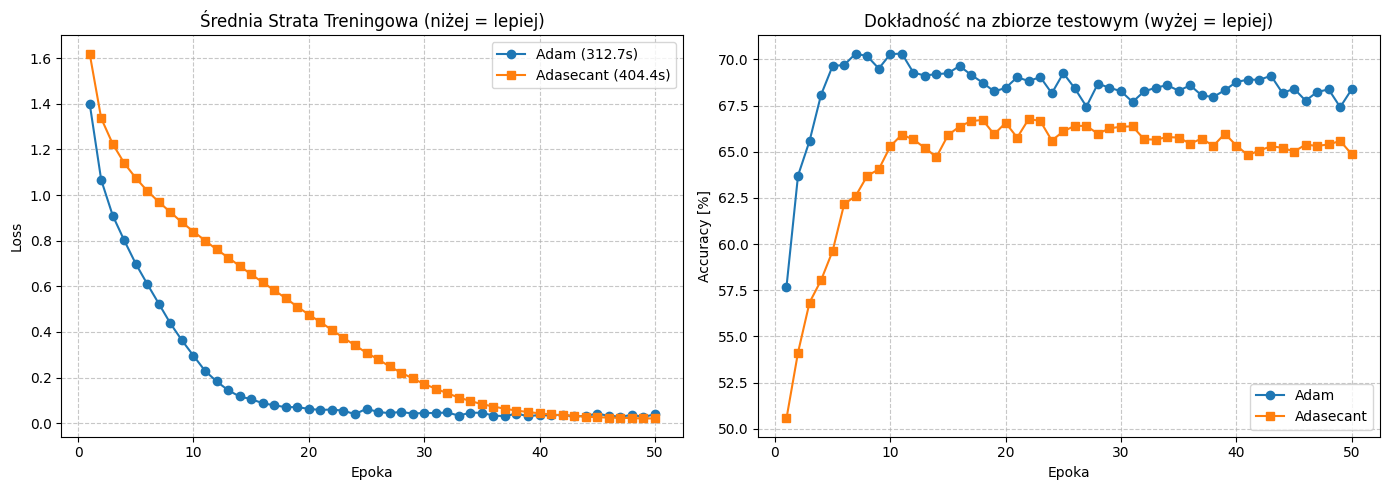

In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim.optimizer import Optimizer
import matplotlib.pyplot as plt
import time

# ==========================================
# 2. DEFINICJA SIECI (Klasyczna mała CNN)
# ==========================================
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 kanały (RGB), 16 filtrów
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Obrazek 32x32 -> 16x16
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # Obrazek 16x16 -> 8x8
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10) # 10 klas na wyjściu
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# ==========================================
# 3. FUNKCJA TRENUJĄCA I REJESTRUJĄCA WYNIKI
# ==========================================
def run_experiment(optimizer_name, device, train_loader, test_loader, epochs=5):
    print(f"\n--- Rozpoczynamy trening przy użyciu optymalizatora: {optimizer_name} ---")
    
    # Inicjalizujemy nową sieć za każdym razem, żeby startowały z podobnego pułapu!
    torch.manual_seed(42) # Dla powtarzalności wyników
    model = SimpleCNN().to(device)
    loss_fn = nn.CrossEntropyLoss()
    
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    else:
        # Tu wchodzi nasz algorytm
        optimizer = Adasecant(model.parameters()) 

    history = {'train_loss': [], 'test_acc': [], 'time': 0}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for batch_idx, (X, y) in enumerate(train_loader):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Ewaluacja po każdej epoce
        model.eval()
        correct = 0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                correct += (pred.argmax(1) == y).type(torch.float).sum().item()
        
        test_acc = correct / len(test_loader.dataset)
        history['test_acc'].append(test_acc)
        
        print(f"Epoka {epoch+1}/{epochs} | Strata (Trening): {avg_train_loss:.4f} | Dokładność (Test): {test_acc*100:.1f}%")

    history['time'] = time.time() - start_time
    print(f"Zakończono w {history['time']:.2f} sekund.")
    return history

# ==========================================
# 4. GŁÓWNA PĘTLA PROGRAMU (Wizualizacja)
# ==========================================
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"Urządzenie: {device}")

    # Transformacje: CIFAR-10 to obrazy 32x32 w kolorze. Normujemy je do zakresu [-1, 1]
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    print("Pobieram zbiór danych CIFAR-10...")
    train_data = datasets.CIFAR10(root="data", train=True, download=True, transform=transform)
    test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=transform)

    batch_size = 64
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    # Ustawiamy liczbę epok (możesz zwiększyć do np. 10-20 dla lepszych wyników)
    NUM_EPOCHS = 50

    # Uruchamiamy dwa eksperymenty
    adam_results = run_experiment("Adam", device, train_loader, test_loader, epochs=NUM_EPOCHS)
    adasecant_results = run_experiment("Adasecant", device, train_loader, test_loader, epochs=NUM_EPOCHS)

    # Wizualizacja wyników
    epochs_range = range(1, NUM_EPOCHS + 1)

    plt.figure(figsize=(14, 5))

    # Wykres Strata (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, adam_results['train_loss'], label=f"Adam ({adam_results['time']:.1f}s)", marker='o')
    plt.plot(epochs_range, adasecant_results['train_loss'], label=f"Adasecant ({adasecant_results['time']:.1f}s)", marker='s')
    plt.title("Średnia Strata Treningowa (niżej = lepiej)")
    plt.xlabel("Epoka")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Wykres Dokładność (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, [acc * 100 for acc in adam_results['test_acc']], label="Adam", marker='o', color='tab:blue')
    plt.plot(epochs_range, [acc * 100 for acc in adasecant_results['test_acc']], label="Adasecant", marker='s', color='tab:orange')
    plt.title("Dokładność na zbiorze testowym (wyżej = lepiej)")
    plt.xlabel("Epoka")
    plt.ylabel("Accuracy [%]")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Łatwy problem sinusoidy

Urządzenie: cuda

--- Trening: Adam ---


/tmp/ipykernel_15772/2082396314.py:17: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  self.X = torch.tensor(self.X, dtype=torch.float32).unsqueeze(-1)


Epoka 1/30 | Strata Trening: 0.17474 | Strata Test: 0.03800
Epoka 5/30 | Strata Trening: 0.01616 | Strata Test: 0.01787
Epoka 10/30 | Strata Trening: 0.01753 | Strata Test: 0.01374
Epoka 15/30 | Strata Trening: 0.01428 | Strata Test: 0.01436
Epoka 20/30 | Strata Trening: 0.01349 | Strata Test: 0.01242
Epoka 25/30 | Strata Trening: 0.01347 | Strata Test: 0.01315
Epoka 30/30 | Strata Trening: 0.01338 | Strata Test: 0.01173
Zakończono w 13.65 s.

--- Trening: Adasecant ---
Epoka 1/30 | Strata Trening: 0.39163 | Strata Test: 0.02973
Epoka 5/30 | Strata Trening: 0.01695 | Strata Test: 0.01493
Epoka 10/30 | Strata Trening: 0.01613 | Strata Test: 0.01373
Epoka 15/30 | Strata Trening: 0.01548 | Strata Test: 0.01583
Epoka 20/30 | Strata Trening: 0.01461 | Strata Test: 0.01279
Epoka 25/30 | Strata Trening: 0.01395 | Strata Test: 0.01193
Epoka 30/30 | Strata Trening: 0.01360 | Strata Test: 0.01175
Zakończono w 10.15 s.


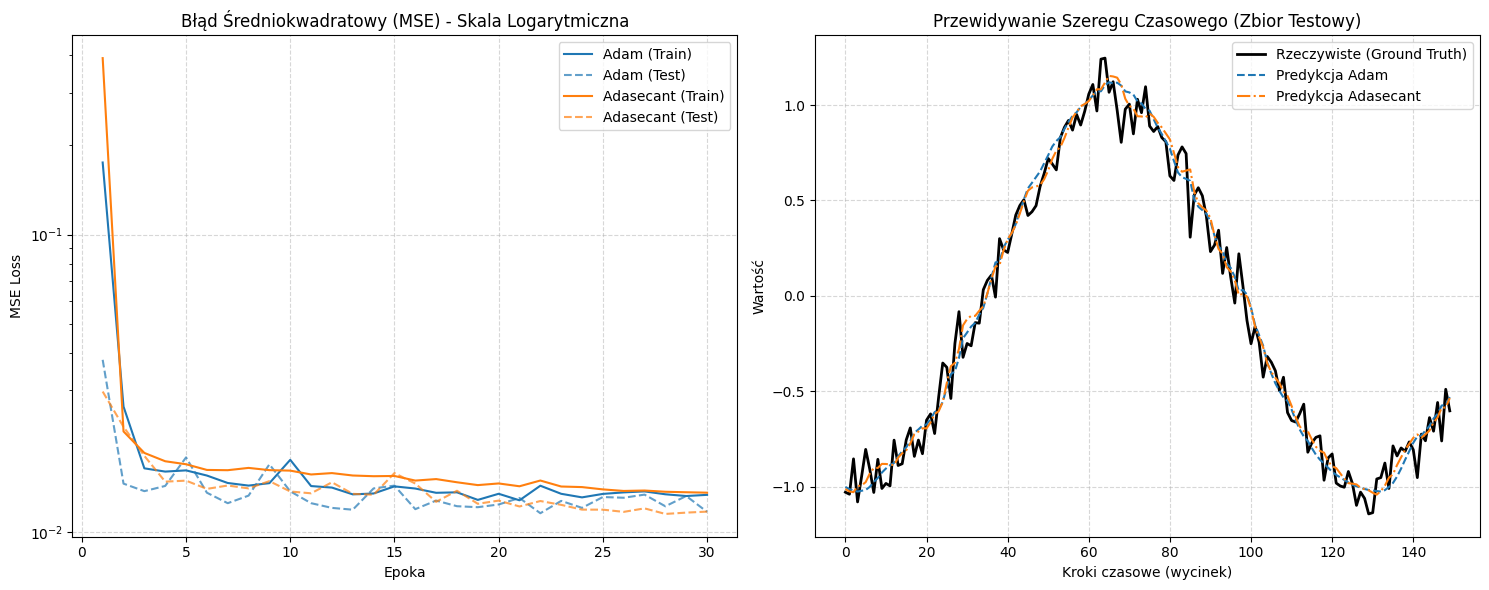

In [4]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 2. ZBIÓR DANYCH (Zaszumiona Sinusoida)
# ==========================================
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length=50):
        self.X = []
        self.y = []
        for i in range(len(data) - seq_length):
            self.X.append(data[i : i + seq_length])
            self.y.append(data[i + seq_length])
            
        self.X = torch.tensor(self.X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(self.y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ==========================================
# 3. DEFINICJA SIECI (LSTM)
# ==========================================
class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        # lstm oczekuje wejścia: (batch, seq_len, features)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] # Bierzemy tylko wynik z ostatniego kroku czasowego sekwencji
        out = self.fc(out)
        return out

# ==========================================
# 4. PĘTLA TRENUJĄCA
# ==========================================
def run_regression_experiment(optimizer_name, device, train_loader, test_loader, epochs=30):
    print(f"\n--- Trening: {optimizer_name} ---")
    
    torch.manual_seed(42) # Stały seed, aby obie sieci startowały z tymi samymi wagami początkowymi
    model = LSTMRegressor().to(device)
    loss_fn = nn.MSELoss() # Błąd średniokwadratowy dla regresji
    
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    else:
        optimizer = Adasecant(model.parameters())

    history = {'train_loss': [], 'test_loss': [], 'time': 0, 'model': model}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Ewaluacja
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                test_loss += loss_fn(pred, y).item()
                
        avg_test_loss = test_loss / len(test_loader)
        history['test_loss'].append(avg_test_loss)
        
        # Wypisujemy logi rzadziej, np. co 5 epok
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoka {epoch+1}/{epochs} | Strata Trening: {avg_train_loss:.5f} | Strata Test: {avg_test_loss:.5f}")

    history['time'] = time.time() - start_time
    print(f"Zakończono w {history['time']:.2f} s.")
    return history

# ==========================================
# 5. GŁÓWNA CZEŚĆ PROGRAMU I WIZUALIZACJA
# ==========================================
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"Urządzenie: {device}")

    # Generowanie danych
    TOTAL_SAMPLES = 2000
    SEQ_LENGTH = 50
    time_steps = np.linspace(0, 100, TOTAL_SAMPLES)
    # Zaszumiona sinusoida
    raw_data = np.sin(time_steps) + np.random.normal(0, 0.1, len(time_steps))

    # Podział w czasie (nie tasujemy! Pierwsze 80% to przeszłość, ostatnie 20% to przyszłość)
    split_idx = int(0.8 * len(raw_data))
    train_data_raw = raw_data[:split_idx]
    test_data_raw = raw_data[split_idx - SEQ_LENGTH:] # Zachodzimy lekko, by mieć sekwencję startową dla testów

    train_dataset = TimeSeriesDataset(train_data_raw, seq_length=SEQ_LENGTH)
    test_dataset = TimeSeriesDataset(test_data_raw, seq_length=SEQ_LENGTH)

    # shuffle=True dla treningu pomaga w stabilności SGD/Adam, test_loader bez tasowania do wizualizacji
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    NUM_EPOCHS = 30 # Optymalnie dla tego zadania

    # Trening
    adam_results = run_regression_experiment("Adam", device, train_loader, test_loader, epochs=NUM_EPOCHS)
    adasecant_results = run_regression_experiment("Adasecant", device, train_loader, test_loader, epochs=NUM_EPOCHS)

    # Przygotowanie danych testowych do wykresu (wyciągamy predykcje)
    adam_model = adam_results['model'].eval()
    adasecant_model = adasecant_results['model'].eval()
    
    X_test_all, y_test_all = [], []
    for X, y in test_loader:
        X_test_all.append(X)
        y_test_all.append(y)
    X_test_all = torch.cat(X_test_all).to(device)
    y_test_all = torch.cat(y_test_all).cpu().numpy().flatten()

    with torch.no_grad():
        preds_adam = adam_model(X_test_all).cpu().numpy().flatten()
        preds_adasecant = adasecant_model(X_test_all).cpu().numpy().flatten()

    # --- WIZUALIZACJA ---
    plt.figure(figsize=(15, 6))

    # Wykres 1: Krzywe straty (uczenia)
    plt.subplot(1, 2, 1)
    epochs_range = range(1, NUM_EPOCHS + 1)
    plt.plot(epochs_range, adam_results['train_loss'], label="Adam (Train)", linestyle='-', color='tab:blue')
    plt.plot(epochs_range, adam_results['test_loss'], label="Adam (Test)", linestyle='--', color='tab:blue', alpha=0.7)
    plt.plot(epochs_range, adasecant_results['train_loss'], label="Adasecant (Train)", linestyle='-', color='tab:orange')
    plt.plot(epochs_range, adasecant_results['test_loss'], label="Adasecant (Test)", linestyle='--', color='tab:orange', alpha=0.7)
    plt.yscale('log') # Skala logarytmiczna lepiej pokazuje różnice przy małych błędach MSE
    plt.title("Błąd Średniokwadratowy (MSE) - Skala Logarytmiczna")
    plt.xlabel("Epoka")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # Wykres 2: Predykcja na wycinku zbioru testowego (ostatnie 150 kroków)
    plt.subplot(1, 2, 2)
    view_range = 150 # Oglądamy tylko wycinek dla czytelności
    plt.plot(y_test_all[-view_range:], label="Rzeczywiste (Ground Truth)", color='black', linewidth=2)
    plt.plot(preds_adam[-view_range:], label="Predykcja Adam", color='tab:blue', linestyle='--')
    plt.plot(preds_adasecant[-view_range:], label="Predykcja Adasecant", color='tab:orange', linestyle='-.')
    plt.title("Przewidywanie Szeregu Czasowego (Zbior Testowy)")
    plt.xlabel("Kroki czasowe (wycinek)")
    plt.ylabel("Wartość")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Test wzorców przestrzennych

Generowanie Atraktora Lorenza...
Używane urządzenie: cuda

--- Rozpoczynam trening (Lorenz 3D): Adam ---
Epoka  1/40 | Strata Trening: 0.932873 | Strata Test: 1.101487
Epoka  5/40 | Strata Trening: 0.142219 | Strata Test: 0.116965
Epoka 10/40 | Strata Trening: 0.020215 | Strata Test: 0.010728
Epoka 15/40 | Strata Trening: 0.004194 | Strata Test: 0.001429
Epoka 20/40 | Strata Trening: 0.000869 | Strata Test: 0.000600
Epoka 25/40 | Strata Trening: 0.000361 | Strata Test: 0.000405
Epoka 30/40 | Strata Trening: 0.000251 | Strata Test: 0.000298
Epoka 35/40 | Strata Trening: 0.000154 | Strata Test: 0.000441
Epoka 40/40 | Strata Trening: 0.000134 | Strata Test: 0.000186
Zakończono w 24.04 s.

--- Rozpoczynam trening (Lorenz 3D): Adasecant ---
Epoka  1/40 | Strata Trening: 0.367725 | Strata Test: 0.053664
Epoka  5/40 | Strata Trening: 0.003630 | Strata Test: 0.002799
Epoka 10/40 | Strata Trening: 0.001491 | Strata Test: 0.002063
Epoka 15/40 | Strata Trening: 0.001093 | Strata Test: 0.000762
Ep

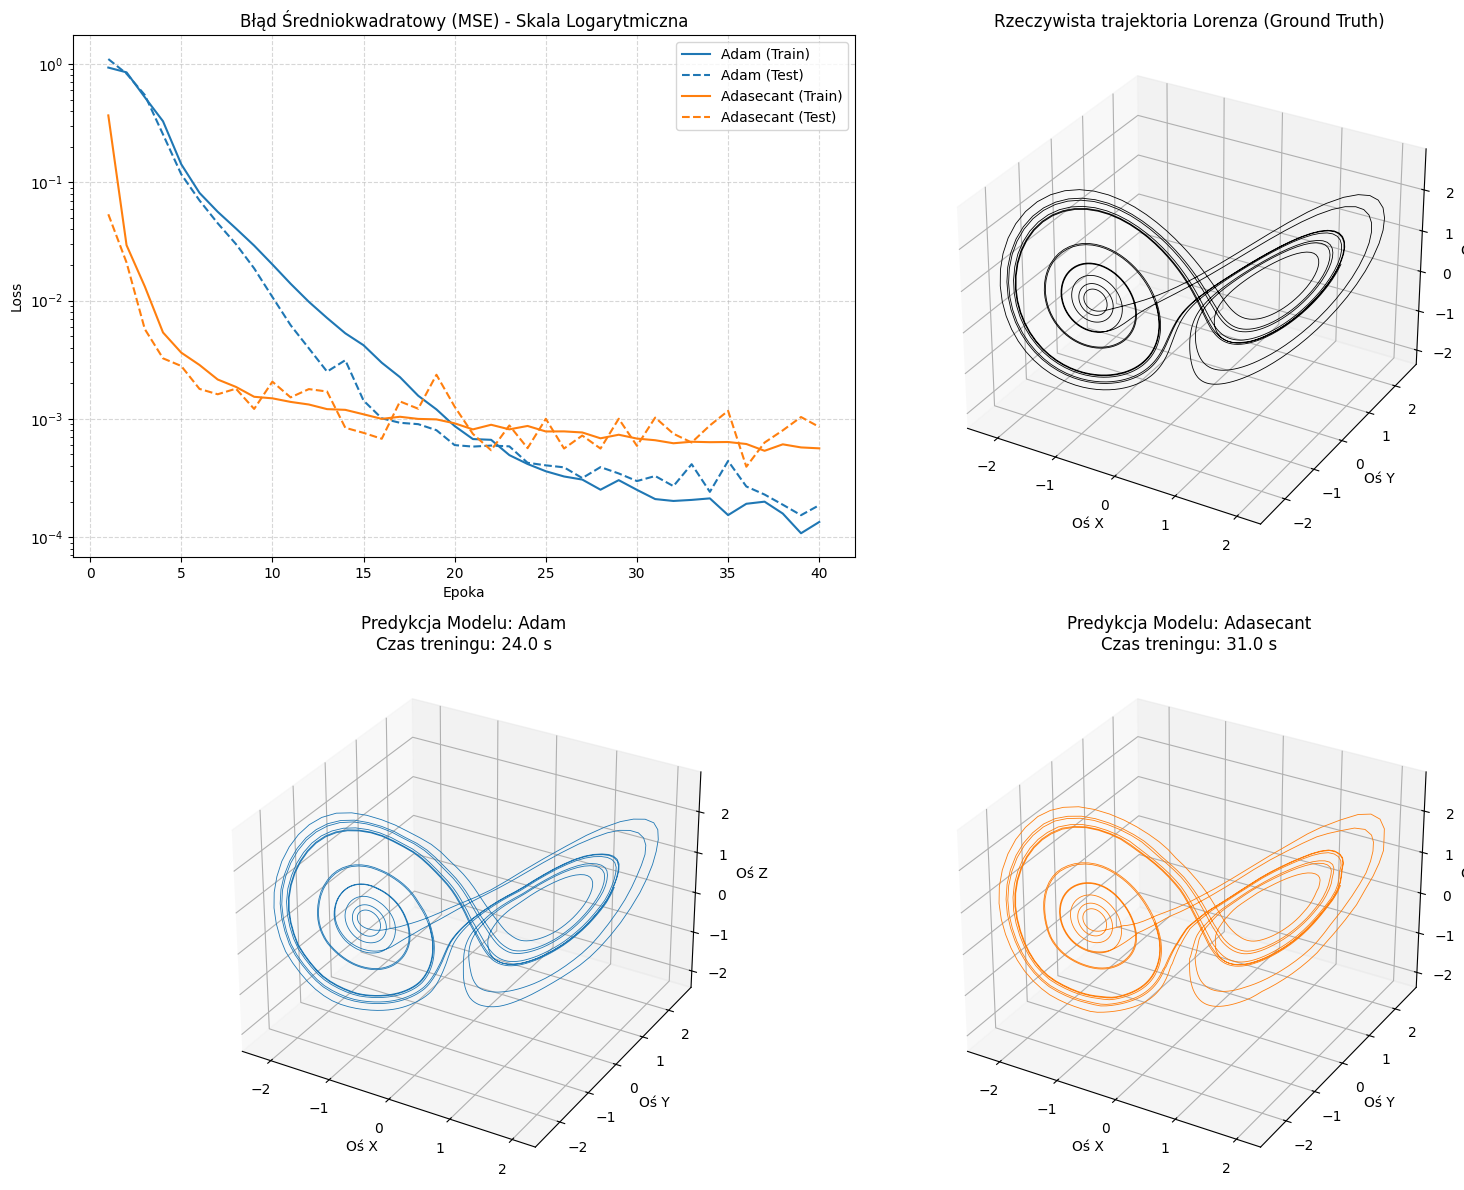

In [6]:
# ==========================================
# 1. GENERATOR DANYCH (Atraktor Lorenza)
# ==========================================
def generate_lorenz(num_steps=5000, dt=0.01):
    """Rozwiązuje równania Lorenza metodą Eulera"""
    xs = np.empty(num_steps)
    ys = np.empty(num_steps)
    zs = np.empty(num_steps)
    
    # Warunki początkowe i parametry (standardowe dla chaosu)
    xs[0], ys[0], zs[0] = (0.0, 1.0, 1.05)
    sigma, rho, beta = 10.0, 28.0, 8.0 / 3.0

    for i in range(num_steps - 1):
        xs[i + 1] = xs[i] + (sigma * (ys[i] - xs[i])) * dt
        ys[i + 1] = ys[i] + (xs[i] * (rho - zs[i]) - ys[i]) * dt
        zs[i + 1] = zs[i] + (xs[i] * ys[i] - beta * zs[i]) * dt
        
    return np.vstack((xs, ys, zs)).T # Zwraca tablicę o kształcie [num_steps, 3]

# Generujemy i normalizujemy dane (Skalowanie jest kluczowe dla sieci!)
print("Generowanie Atraktora Lorenza...")
raw_data = generate_lorenz(num_steps=6000)
data_mean = raw_data.mean(axis=0)
data_std = raw_data.std(axis=0)
normalized_data = (raw_data - data_mean) / data_std

# ==========================================
# 2. DATASET DLA SYSTEMU 3D
# ==========================================
class LorenzDataset(Dataset):
    def __init__(self, data, seq_length=20):
        self.X = []
        self.y = []
        for i in range(len(data) - seq_length):
            self.X.append(data[i : i + seq_length])
            self.y.append(data[i + seq_length]) # Przewidujemy kolejny punkt w 3D
            
        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

SEQ_LENGTH = 50 
split_idx = 4500

train_dataset = LorenzDataset(normalized_data[:split_idx], seq_length=SEQ_LENGTH)
test_dataset = LorenzDataset(normalized_data[split_idx - SEQ_LENGTH:], seq_length=SEQ_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# ==========================================
# 3. GŁĘBSZA SIEĆ LSTM (Dla trudniejszego zadania)
# ==========================================
class DeepLSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, num_layers=3):
        super().__init__()
        # Zauważ wejście=3 (wymiary X, Y, Z) i znacznie więcej neuronów ukrytych
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.0)
        
        # Kilka warstw gęstych na wyjściu do lepszej interpretacji cech
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 3) # Wyjście to punkt w 3D (X, Y, Z)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :] 
        out = self.fc(out)
        return out


# ==========================================
# 4. PĘTLA TRENUJĄCA
# ==========================================
def run_lorenz_experiment(optimizer_name, device, train_loader, test_loader, epochs=40):
    print(f"\n--- Rozpoczynam trening (Lorenz 3D): {optimizer_name} ---")
    
    # Inicjalizacja sieci zdefiniowanej w Kroku 3
    torch.manual_seed(42) 
    model = DeepLSTM(input_size=3, hidden_size=128, num_layers=3).to(device)
    loss_fn = nn.MSELoss() 
    
    if optimizer_name == "Adam":
        # Learning rate dla Adama często wymaga tuningu, 0.001 to dobry start
        optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    else:
        # Nasz własny optymalizator Adasecant
        optimizer = Adasecant(model.parameters())

    history = {'train_loss': [], 'test_loss': [], 'time': 0, 'model': model}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            
            pred = model(X)
            loss = loss_fn(pred, y)
            
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # Ewaluacja na danych testowych (przyszłość)
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                pred = model(X)
                test_loss += loss_fn(pred, y).item()
                
        avg_test_loss = test_loss / len(test_loader)
        history['test_loss'].append(avg_test_loss)
        
        # Mniej agresywne logowanie w konsoli (co 5 epok)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoka {epoch+1:>2}/{epochs} | Strata Trening: {avg_train_loss:.6f} | Strata Test: {avg_test_loss:.6f}")

    history['time'] = time.time() - start_time
    print(f"Zakończono w {history['time']:.2f} s.")
    return history

# ==========================================
# 5. GŁÓWNA CZĘŚĆ PROGRAMU I WIZUALIZACJA 3D
# ==========================================
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
    print(f"Używane urządzenie: {device}")

    # (Zakładam, że train_loader i test_loader zostały utworzone w sekcji 2)
    NUM_EPOCHS = 40

    # Uruchamiamy starcie algorytmów
    adam_results = run_lorenz_experiment("Adam", device, train_loader, test_loader, epochs=NUM_EPOCHS)
    adasecant_results = run_lorenz_experiment("Adasecant", device, train_loader, test_loader, epochs=NUM_EPOCHS)

    # --- PRZYGOTOWANIE WYNIKÓW DO WIZUALIZACJI ---
    adam_model = adam_results['model'].eval()
    adasecant_model = adasecant_results['model'].eval()
    
    # Zbieramy wszystkie dane z test_loader w jeden duży tensor, aby narysować pełną trasę
    X_test_all, y_test_all = [], []
    for X, y in test_loader:
        X_test_all.append(X)
        y_test_all.append(y)
    
    X_test_all = torch.cat(X_test_all).to(device)
    y_test_all = torch.cat(y_test_all).cpu().numpy()

    # Wyliczamy predykcje dla całego zbioru testowego naraz
    with torch.no_grad():
        preds_adam = adam_model(X_test_all).cpu().numpy()
        preds_adasecant = adasecant_model(X_test_all).cpu().numpy()

    # --- RYSOWANIE WYKRESÓW (Układ 2x2) ---
    fig = plt.figure(figsize=(16, 12))

    # [Góra-Lewo] Wykres krzywych uczenia (Loss)
    ax1 = fig.add_subplot(2, 2, 1)
    epochs_range = range(1, NUM_EPOCHS + 1)
    ax1.plot(epochs_range, adam_results['train_loss'], label="Adam (Train)", color='tab:blue')
    ax1.plot(epochs_range, adam_results['test_loss'], label="Adam (Test)", color='tab:blue', linestyle='--')
    ax1.plot(epochs_range, adasecant_results['train_loss'], label="Adasecant (Train)", color='tab:orange')
    ax1.plot(epochs_range, adasecant_results['test_loss'], label="Adasecant (Test)", color='tab:orange', linestyle='--')
    
    ax1.set_yscale('log') # Skala logarytmiczna wyciąga na wierzch różnice, gdy błąd jest bliski 0
    ax1.set_title("Błąd Średniokwadratowy (MSE) - Skala Logarytmiczna")
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.5)

    # [Góra-Prawo] Prawdziwy Atraktor (Wzorzec)
    ax2 = fig.add_subplot(2, 2, 2, projection='3d')
    # Rysujemy linię łączącą punkty X, Y, Z
    ax2.plot(y_test_all[:, 0], y_test_all[:, 1], y_test_all[:, 2], color='black', linewidth=0.6)
    ax2.set_title("Rzeczywista trajektoria Lorenza (Ground Truth)")

    # [Dół-Lewo] Predykcja algorytmu Adam
    ax3 = fig.add_subplot(2, 2, 3, projection='3d')
    ax3.plot(preds_adam[:, 0], preds_adam[:, 1], preds_adam[:, 2], color='tab:blue', linewidth=0.6)
    ax3.set_title(f"Predykcja Modelu: Adam\nCzas treningu: {adam_results['time']:.1f} s")

    # [Dół-Prawo] Predykcja Waszego optymalizatora Adasecant
    ax4 = fig.add_subplot(2, 2, 4, projection='3d')
    ax4.plot(preds_adasecant[:, 0], preds_adasecant[:, 1], preds_adasecant[:, 2], color='tab:orange', linewidth=0.6)
    ax4.set_title(f"Predykcja Modelu: Adasecant\nCzas treningu: {adasecant_results['time']:.1f} s")

    # Dodatkowe ustawienia dla spójnego wyglądu osi 3D
    for ax in [ax2, ax3, ax4]:
        ax.set_xlabel('Oś X')
        ax.set_ylabel('Oś Y')
        ax.set_zlabel('Oś Z')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Test na Variational AutoEncoderze

Urządzenie: cuda


100%|██████████| 9.91M/9.91M [00:26<00:00, 370kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 147kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 568kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.2MB/s]



--- Trening VAE: Adam ---
Epoka 1/15 | Średnia strata: 190.0120
Epoka 2/15 | Średnia strata: 168.7982
Epoka 3/15 | Średnia strata: 163.7880
Epoka 4/15 | Średnia strata: 160.3778
Epoka 5/15 | Średnia strata: 158.1896
Epoka 6/15 | Średnia strata: 156.6628
Epoka 7/15 | Średnia strata: 155.4049
Epoka 8/15 | Średnia strata: 154.4411
Epoka 9/15 | Średnia strata: 153.5779
Epoka 10/15 | Średnia strata: 152.8656
Epoka 11/15 | Średnia strata: 152.1605
Epoka 12/15 | Średnia strata: 151.6218
Epoka 13/15 | Średnia strata: 151.1315
Epoka 14/15 | Średnia strata: 150.6634
Epoka 15/15 | Średnia strata: 150.2455

--- Trening VAE: Adasecant ---
Epoka 1/15 | Średnia strata: 176.1718
Epoka 2/15 | Średnia strata: 166.6147
Epoka 3/15 | Średnia strata: 164.2639
Epoka 4/15 | Średnia strata: 162.6654
Epoka 5/15 | Średnia strata: 161.4476
Epoka 6/15 | Średnia strata: 160.4167
Epoka 7/15 | Średnia strata: 159.5980
Epoka 8/15 | Średnia strata: 158.8561
Epoka 9/15 | Średnia strata: 158.1999
Epoka 10/15 | Średnia s

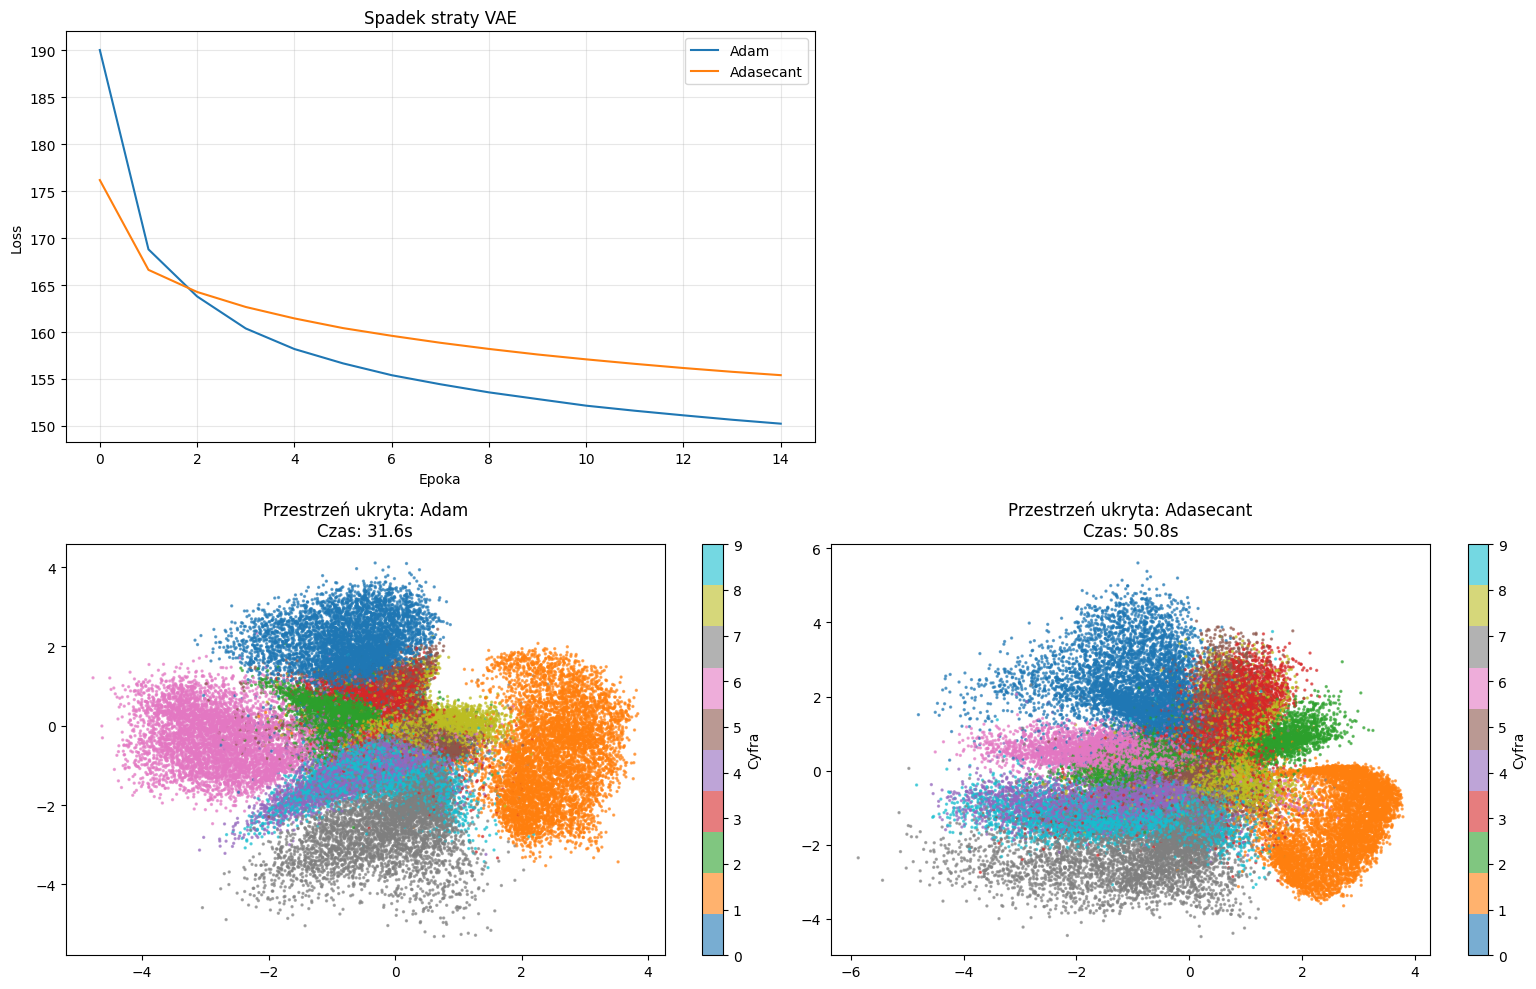

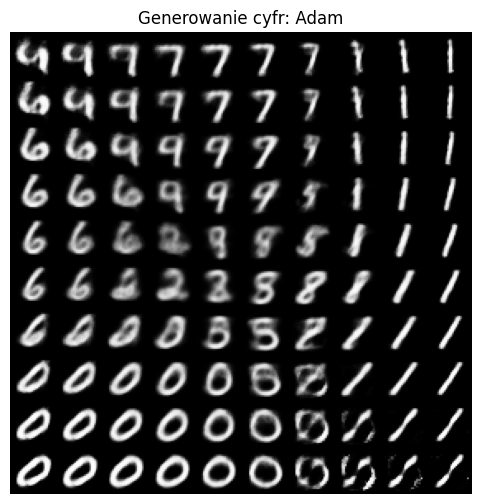

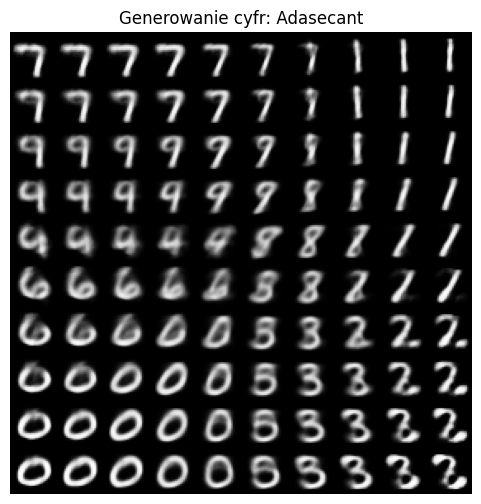

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time

# ==========================================
# 1. ARCHITEKTURA VAE
# ==========================================
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        
        # ENKODER: Obraz (28x28=784) -> Przestrzeń ukryta
        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, latent_dim) # mu (średnia)
        self.fc22 = nn.Linear(400, latent_dim) # logvar (wariancja)
        
        # DEKODER: Przestrzeń ukryta -> Obraz
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Funkcja straty VAE: Rekonstrukcja + Dywergencja KL
def vae_loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    # KL Divergence: dążymy do tego, by rozkład był bliski N(0,1)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# ==========================================
# 2. FUNKCJA TRENUJĄCA
# ==========================================
def run_vae_experiment(optimizer_name, device, train_loader, epochs=15, latent_dim=2):
    print(f"\n--- Trening VAE: {optimizer_name} ---")
    model = VAE(latent_dim=latent_dim).to(device)
    
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    else:
        # Zakładamy, że Adasecant jest dostępny w namespace
        optimizer = Adasecant(model.parameters())

    history = {'loss': [], 'time': 0, 'latent_points': [], 'labels': []}
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0
        for batch_idx, (data, labels) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            
            recon_batch, mu, logvar = model(data)
            loss = vae_loss_function(recon_batch, data, mu, logvar)
            
            loss.backward()
            train_loss += loss.item()
            optimizer.step()

            # Zbieramy punkty z przestrzeni ukrytej do wizualizacji (tylko ostatnia epoka)
            if epoch == epochs:
                history['latent_points'].append(mu.detach().cpu().numpy())
                history['labels'].append(labels.numpy())

        avg_loss = train_loss / len(train_loader.dataset)
        history['loss'].append(avg_loss)
        print(f'Epoka {epoch}/{epochs} | Średnia strata: {avg_loss:.4f}')

    history['time'] = time.time() - start_time
    history['latent_points'] = np.concatenate(history['latent_points'])
    history['labels'] = np.concatenate(history['labels'])
    return history, model

# ==========================================
# 3. GŁÓWNA CZĘŚĆ (MNIST + WIZUALIZACJA)
# ==========================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Urządzenie: {device}")

    # Ładowanie MNIST
    train_loader = DataLoader(
        datasets.MNIST('./data', train=True, download=True, transform=transforms.ToTensor()),
        batch_size=128, shuffle=True)

    NUM_EPOCHS = 15
    LATENT_DIM = 2 # 2 wymiary, żeby łatwo narysować mapę 2D

    adam_results, adam_model = run_vae_experiment("Adam", device, train_loader, epochs=NUM_EPOCHS)
    adasecant_results, adasecant_model = run_vae_experiment("Adasecant", device, train_loader, epochs=NUM_EPOCHS)

    # --- WIZUALIZACJA WYNIKÓW ---
    plt.figure(figsize=(16, 10))

    # Wykres 1: Porównanie strat
    plt.subplot(2, 2, 1)
    plt.plot(adam_results['loss'], label='Adam')
    plt.plot(adasecant_results['loss'], label='Adasecant')
    plt.title("Spadek straty VAE")
    plt.xlabel("Epoka")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Wykres 2: Przestrzeń ukryta (Latent Space) - ADAM
    plt.subplot(2, 2, 3)
    plt.scatter(adam_results['latent_points'][:, 0], adam_results['latent_points'][:, 1], 
                c=adam_results['labels'], cmap='tab10', s=2, alpha=0.6)
    plt.colorbar(label='Cyfra')
    plt.title(f"Przestrzeń ukryta: Adam\nCzas: {adam_results['time']:.1f}s")

    # Wykres 3: Przestrzeń ukryta (Latent Space) - ADASECANT
    plt.subplot(2, 2, 4)
    plt.scatter(adasecant_results['latent_points'][:, 0], adasecant_results['latent_points'][:, 1], 
                c=adasecant_results['labels'], cmap='tab10', s=2, alpha=0.6)
    plt.colorbar(label='Cyfra')
    plt.title(f"Przestrzeń ukryta: Adasecant\nCzas: {adasecant_results['time']:.1f}s")

    plt.tight_layout()
    plt.show()

    # Wyświetlenie rekonstrukcji
    def plot_reconstructions(model, device, title):
        model.eval()
        with torch.no_grad():
            # Generujemy obrazki z siatki punktów w przestrzeni ukrytej
            n = 10
            digit_size = 28
            figure = np.zeros((digit_size * n, digit_size * n))
            grid_x = np.linspace(-3, 3, n)
            grid_y = np.linspace(-3, 3, n)

            for i, yi in enumerate(grid_x):
                for j, xi in enumerate(grid_y):
                    z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
                    x_decoded = model.decode(z_sample)
                    digit = x_decoded[0].reshape(digit_size, digit_size).cpu().numpy()
                    figure[i * digit_size: (i + 1) * digit_size,
                           j * digit_size: (j + 1) * digit_size] = digit

            plt.figure(figsize=(6, 6))
            plt.imshow(figure, cmap='Greys_r')
            plt.title(title)
            plt.axis('off')
            plt.show()

    plot_reconstructions(adam_model, device, "Generowanie cyfr: Adam")
    plot_reconstructions(adasecant_model, device, "Generowanie cyfr: Adasecant")

# Transfer learning 

Urządzenie obliczeniowe: cuda
Pobieranie i przygotowywanie zbioru Flowers102...


100%|██████████| 345M/345M [02:12<00:00, 2.61MB/s] 
100%|██████████| 502/502 [00:00<00:00, 7.52MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 67.3MB/s]



--- Trening Flowers102: Adam ---
Epoka  1/50 | Strata (Trening): 4.5120 | Dokładność (Test): 19.17%
Epoka  5/50 | Strata (Trening): 1.9667 | Dokładność (Test): 75.88%
Epoka 10/50 | Strata (Trening): 0.8641 | Dokładność (Test): 85.82%
Epoka 15/50 | Strata (Trening): 0.5185 | Dokładność (Test): 89.28%
Epoka 20/50 | Strata (Trening): 0.2848 | Dokładność (Test): 90.01%
Epoka 25/50 | Strata (Trening): 0.2194 | Dokładność (Test): 90.67%
Epoka 30/50 | Strata (Trening): 0.1774 | Dokładność (Test): 90.50%
Epoka 35/50 | Strata (Trening): 0.1569 | Dokładność (Test): 91.15%
Epoka 40/50 | Strata (Trening): 0.1492 | Dokładność (Test): 90.88%
Epoka 45/50 | Strata (Trening): 0.1092 | Dokładność (Test): 90.60%
Epoka 50/50 | Strata (Trening): 0.0893 | Dokładność (Test): 90.91%
Zakończono w 288.3 s.

--- Trening Flowers102: Adasecant ---
Epoka  1/50 | Strata (Trening): 3.8588 | Dokładność (Test): 53.08%
Epoka  5/50 | Strata (Trening): 0.3645 | Dokładność (Test): 84.16%
Epoka 10/50 | Strata (Trening): 0.

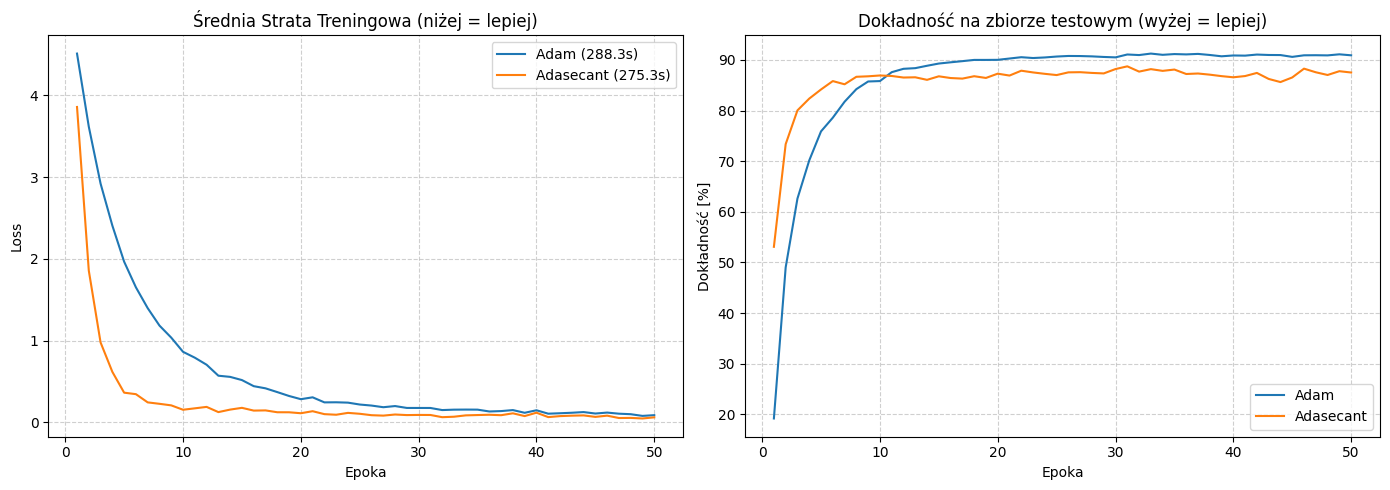

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. PRZYGOTOWANIE MODELU (Transfer Learning)
# ==========================================
def get_finetune_model(num_classes=102):
    # Pobieramy wagi ResNet-18 wytrenowane na ImageNet
    model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    
    # KROK 1: Zamrażamy wszystkie warstwy
    for param in model.parameters():
        param.requires_grad = False
        
    # KROK 2: Odmrażamy tylko ostatni blok (layer4)
    for param in model.layer4.parameters():
        param.requires_grad = True
        
    # KROK 3: Podmieniamy warstwę klasyfikującą z 1000 na 102 klasy (kwiaty)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    
    return model

# ==========================================
# 2. FUNKCJA TRENUJĄCA
# ==========================================
def run_flowers_experiment(optimizer_name, device, train_loader, test_loader, epochs=50):
    print(f"\n--- Trening Flowers102: {optimizer_name} ---")
    
    torch.manual_seed(42)
    model = get_finetune_model(num_classes=102).to(device)
    loss_fn = nn.CrossEntropyLoss()
    
    # Przekazujemy do optymalizatora tylko odmrożone wagi (layer4 + fc)
    active_parameters = filter(lambda p: p.requires_grad, model.parameters())
    
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(active_parameters, lr=1e-4) 
    else:
        # Wasz algorytm: Adasecant
        optimizer = Adasecant(active_parameters) 

    history = {'train_loss': [], 'test_acc': [], 'time': 0}
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        # --- TRENING ---
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)
        
        # --- EWALUACJA (na potężnym zbiorze testowym) ---
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        test_acc = 100 * correct / total
        history['test_acc'].append(test_acc)
        
        # Wypisujemy logi co 5 epok, aby nie zaspamować konsoli
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoka {epoch:>2}/{epochs} | Strata (Trening): {avg_train_loss:.4f} | Dokładność (Test): {test_acc:.2f}%")

    history['time'] = time.time() - start_time
    print(f"Zakończono w {history['time']:.1f} s.")
    return history

# ==========================================
# 3. GŁÓWNA CZĘŚĆ PROGRAMU I WIZUALIZACJA
# ==========================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Urządzenie obliczeniowe: {device}")

    # Standardowe transformacje wymuszające uogólnianie (szczególnie ważne dla małych zbiorów!)
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    print("Pobieranie i przygotowywanie zbioru Flowers102...")
    # UWAGA: W zbiorze Flowers102 używamy argumentu `split` zamiast `train`
    train_dataset = datasets.Flowers102(root='./data', split='train', download=True, transform=train_transform)
    test_dataset = datasets.Flowers102(root='./data', split='test', download=True, transform=test_transform)

    # Ze względu na mały zbiór treningowy (1020 obrazków), batch_size=32 lub 64 to dobry balans
    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    # Puszczamy eksperyment na długi dystans
    NUM_EPOCHS = 50 

    adam_results = run_flowers_experiment("Adam", device, train_loader, test_loader, epochs=NUM_EPOCHS)
    adasecant_results = run_flowers_experiment("Adasecant", device, train_loader, test_loader, epochs=NUM_EPOCHS)

    # --- RYSOWANIE WYKRESÓW ---
    epochs_range = range(1, NUM_EPOCHS + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Wykres Strata (Loss)
    ax1.plot(epochs_range, adam_results['train_loss'], label=f"Adam ({adam_results['time']:.1f}s)", color='tab:blue')
    ax1.plot(epochs_range, adasecant_results['train_loss'], label=f"Adasecant ({adasecant_results['time']:.1f}s)", color='tab:orange')
    ax1.set_title("Średnia Strata Treningowa (niżej = lepiej)")
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Wykres Dokładność (Accuracy)
    ax2.plot(epochs_range, adam_results['test_acc'], label="Adam", color='tab:blue')
    ax2.plot(epochs_range, adasecant_results['test_acc'], label="Adasecant", color='tab:orange')
    ax2.set_title("Dokładność na zbiorze testowym (wyżej = lepiej)")
    ax2.set_xlabel("Epoka")
    ax2.set_ylabel("Dokładność [%]")
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()